# Genomics of Drug Sensitivity in Cancer (GDSC) — Analysis Notebook

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning / dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.feature_selection import SelectKBest

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

# Clustering

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
TARGET_COLUMN = 'LN_IC50'
RANDOM_SEED = 42

## 1. Data Loading

In [ ]:
gdsc = pd.read_excel("../data/GDSC.xlsx")

In [3]:
#gdsc = pd.read_excel("https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx")

In [4]:
gdsc.head(5)

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [5]:
gdsc.dtypes

,0
COSMIC_ID,int64
CELL_LINE_NAME,object
TCGA_DESC,object
DRUG_ID,int64
DRUG_NAME,object
LN_IC50,float64
AUC,float64
Z_SCORE,float64
GDSC Tissue descriptor 1,object
GDSC Tissue descriptor 2,object


## MACHINE LEARNING MODELING - PREDICTING LN_IC50

### Preprocessing

Identifiers convey not meaningful biological information, therefore they should be excluded from the dataset. **AUC**, and **Z_SCORE** are alternative measurements of the same information captured by **LN_IC50**. To prevent the introduction of data leakage, they will be exluded as well.

In [6]:
to_excludes = ["COSMIC_ID", "DRUG_ID", "Z_SCORE", "AUC", "Cancer Type (matching TCGA label)"]
df = gdsc.copy()
df.drop(columns=to_excludes, inplace=True)

# Cast all non-numeric columns to 'category'
categorical_columns = df.select_dtypes(exclude='number').columns
for col in categorical_columns:
    df[col] = df[col].astype('category')

print(f"Categorical columns: {list(categorical_columns)}")
print(f"Dataset shape: {df.shape}")

Categorical columns: ['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']
Dataset shape: (162103, 14)


### SPLIT THE DATASET: TRAINING AND TEST SETS

In [7]:
y = df[TARGET_COLUMN]
X = df.drop(columns=TARGET_COLUMN)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (129682, 13), X_test: (32421, 13)


In [8]:
from sklearn.preprocessing import TargetEncoder

categorical_columns = X_train.select_dtypes(exclude='number').columns.tolist()
numeric_columns = X_train.select_dtypes(include='number').columns.tolist()

# Target encoder with built-in cross-fitting to prevent leakage
te = TargetEncoder(
    target_type='continuous',
    cv=5,
    smooth='auto',
    random_state=RANDOM_SEED
)

# Fit on train, transform both
X_train_te = X_train.copy()
X_test_te = X_test.copy()

X_train_te[categorical_columns] = te.fit_transform(X_train[categorical_columns], y_train)
X_test_te[categorical_columns]  = te.transform(X_test[categorical_columns])

print(f"Shape after target encoding: {X_train_te.shape}")  # Same as original

Shape after target encoding: (129682, 13)


## MODELING

In [9]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    max_features='sqrt',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf.fit(X_train_te, y_train)


RandomForestRegressor(max_features='sqrt', min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = rf.predict(X_test_te)

mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.8299
RMSE: 1.1113
R²  : 0.8473


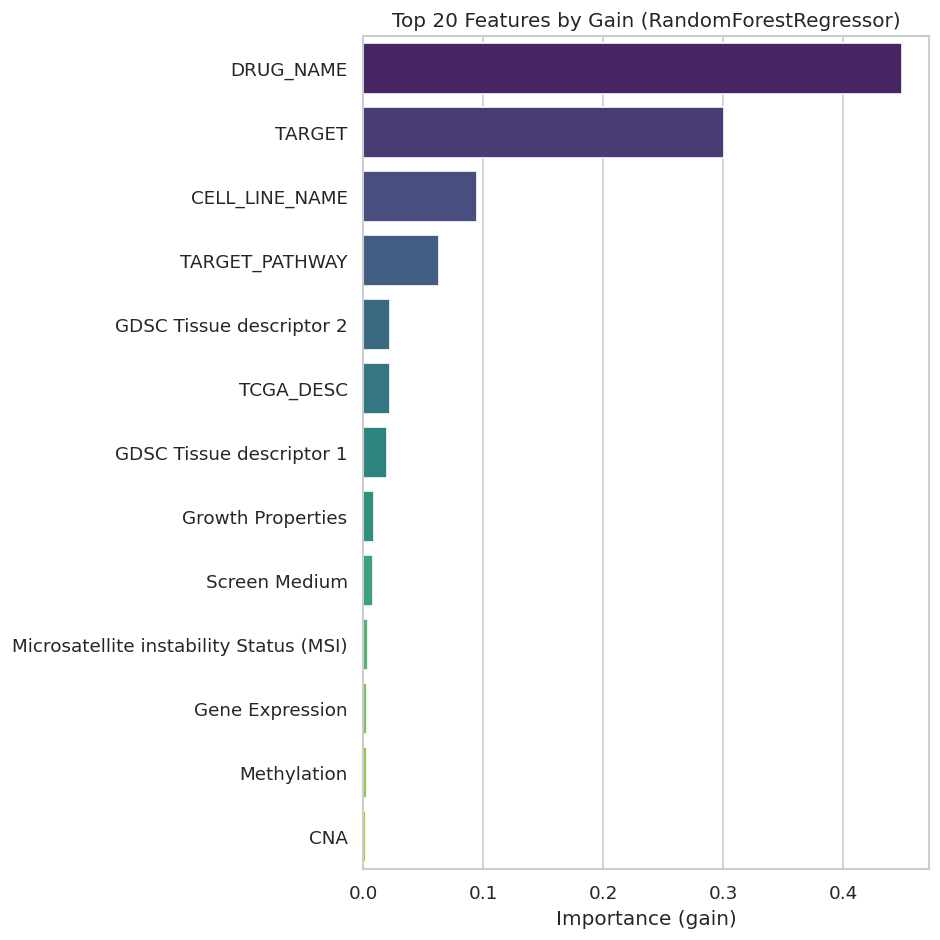

,feature,importance
2,DRUG_NAME,0.448697
11,TARGET,0.300559
0,CELL_LINE_NAME,0.094388
12,TARGET_PATHWAY,0.063002
4,GDSC Tissue descriptor 2,0.022396
1,TCGA_DESC,0.022247
3,GDSC Tissue descriptor 1,0.019306
7,Growth Properties,0.008735
6,Screen Medium,0.007695
5,Microsatellite instability Status (MSI),0.004124


In [11]:

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_  # uses 'gain' by default
}).sort_values('importance', ascending=False)

# Top 20
plt.figure(figsize=(8, 8))
sns.barplot(
    data=importance_df.head(20),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 20 Features by Gain (RandomForestRegressor)')
plt.xlabel('Importance (gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(importance_df.head(20))

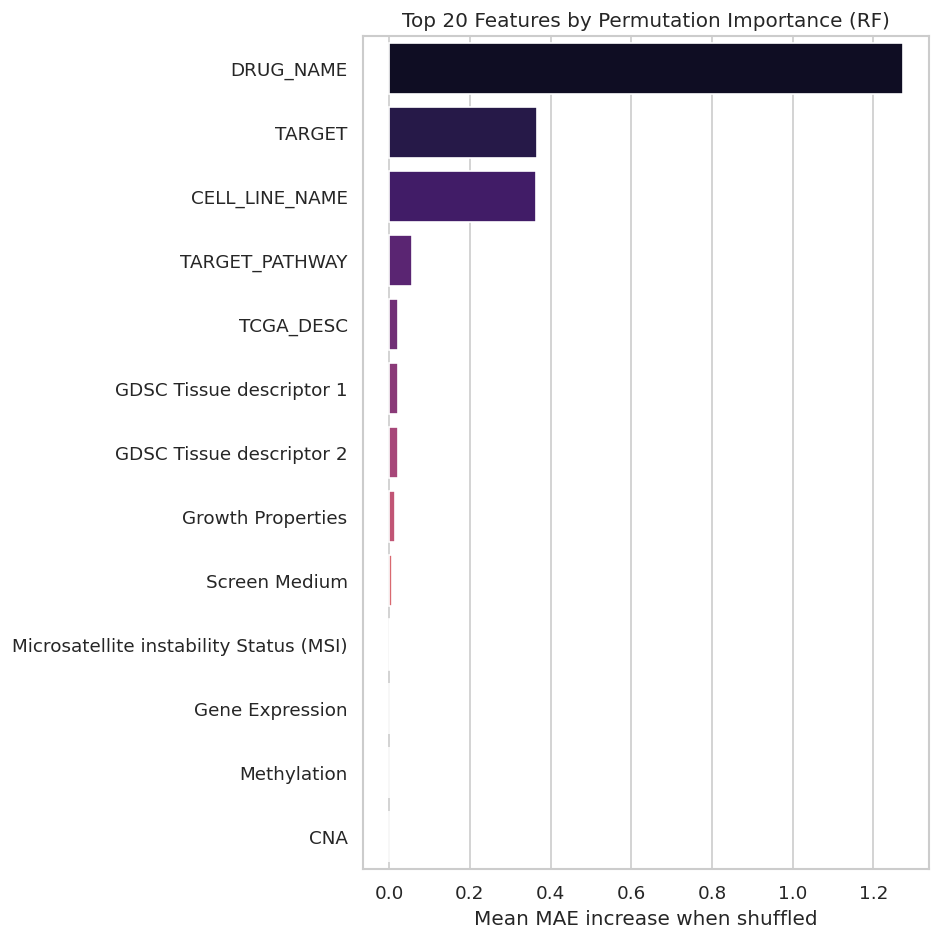

,feature,importance_mean,importance_std
2,DRUG_NAME,1.273472e+00,5.189234e-03
11,TARGET,3.674097e-01,2.384561e-03
0,CELL_LINE_NAME,3.639386e-01,1.627712e-03
12,TARGET_PATHWAY,5.603775e-02,1.319276e-03
1,TCGA_DESC,2.113910e-02,6.561042e-04
3,GDSC Tissue descriptor 1,2.108831e-02,5.582775e-04
4,GDSC Tissue descriptor 2,2.103114e-02,6.789553e-04
7,Growth Properties,1.380155e-02,5.453516e-04
6,Screen Medium,6.247607e-03,4.018786e-04
5,Microsatellite instability Status (MSI),1.219001e-03,2.662479e-04


In [18]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test_te, y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=1, # Choosing 1 makes it run sequentially instead of in parallel (if -1), to avoid 'No space left on device' error
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature': X_test_te.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(
    data=perm_df.head(20),
    x='importance_mean',
    y='feature',
    palette='magma'
)
plt.title('Top 20 Features by Permutation Importance (RF)')
plt.xlabel('Mean MAE increase when shuffled')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(perm_df.head(20))